# When OLS Fails: Advanced Regression for Non-Standard Outcomes

Executed analysis notebook. Fits five regression models — Poisson, negative binomial, ordinal logistic, truncated, and Tobit — each on a dataset whose outcome structure makes ordinary least squares inappropriate, and compares each against OLS. See `02_Project_Report.md` for the full write-up.

*Reproducibility:* awards, world-values, and scores analyses use the public CSVs in this folder; the affairs/Tobit section uses a clearly-labelled synthetic dataset generated deterministically here (`01d_affairs.csv`).

In [1]:
%matplotlib inline

In [2]:
# =============================================================================
# When OLS Fails: Poisson, Negative Binomial, Ordinal, Truncated, and Tobit
# Regression for Non-Standard Outcomes
#
# Author : Mintay Misgano, PhD
# Purpose: One reproducible pipeline that fits five regression models, each on a
#          dataset whose outcome structure makes ordinary least squares (OLS)
#          inappropriate, and compares every model directly against OLS to show
#          what the misspecification costs.
#
# Reproducibility:
#   - Awards, World Values, and Scores analyses use the public CSVs shipped in
#     this project folder (01a/01b/01c).
#   - The affairs/Tobit analysis uses a clearly-labelled SYNTHETIC illustrative
#     dataset generated deterministically here (fixed seed) and written to
#     01d_affairs.csv, so the censored-regression demonstration is fully
#     reproducible without depending on a licensed dataset.
#   - All seven figures are written to docs/figures/ with stable filenames that
#     the README, summary, and report reference.
#
# Run:  python 04_Analysis.py   (regenerates data file, figures, and console
#       output). 03_Analysis.ipynb is the executed, GitHub-viewable version.
# =============================================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib

# Use a headless backend only when running as a plain script; inside a notebook
# kernel the inline backend stays active so every figure renders in the cell.
try:
    get_ipython()  # defined only inside IPython / Jupyter
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Keep console and notebook output clean (e.g. the negative-binomial default-alpha
# note); results are unaffected.
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy import stats, optimize

# Resolve paths relative to this file so the workflow runs from the project
# folder or the repository root without any private/absolute local paths.
# Works both as a standalone script (__file__ defined) and inside a notebook
# (executed with the project folder as the working directory).
HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
FIG = os.path.join(HERE, "docs", "figures")
os.makedirs(FIG, exist_ok=True)

# A single consistent palette so every figure reads the same way: greys for the
# baseline/biased model, saturated colours for the correctly specified model.
C_GREY, C_BLUE, C_GREEN, C_ORANGE, C_PURPLE, C_RED = (
    "#616161", "#1976D2", "#388E3C", "#F57C00", "#7B1FA2", "#C62828",
)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.axisbelow": True})

## Parts 1–2 — Poisson and Negative Binomial regression (academic award counts)

In [3]:
# =============================================================================
# PART 1 - POISSON REGRESSION: academic award counts
# -----------------------------------------------------------------------------
# Poisson regression is a generalized linear model for count outcomes. It uses a
# log link, so exponentiating a coefficient gives an incidence rate ratio (IRR):
# the multiplicative change in expected count per one-unit increase in the
# predictor. OLS is wrong here because it can predict negative counts and assumes
# normal residuals, neither of which holds for a non-negative integer with a
# floor at zero.
# =============================================================================
awards = pd.read_csv(os.path.join(HERE, "01a_awards.csv"))
# Map the numeric programme codes to readable labels and set General as the
# reference category so coefficients compare each programme against General.
awards["prog"] = awards["prog"].map({1: "General", 2: "Academic", 3: "Vocational"})
awards["prog"] = pd.Categorical(awards["prog"],
                                categories=["General", "Academic", "Vocational"])

print("=" * 70)
print("PART 1-2: AWARDS (N = %d)" % len(awards))
print("  mean=%.3f  var=%.3f  pct zero=%.1f%%"
      % (awards.num_awards.mean(), awards.num_awards.var(),
         (awards.num_awards == 0).mean() * 100))

# Fit the Poisson GLM. family=Poisson() applies the log link and Poisson variance.
poisson = sm.GLM.from_formula("num_awards ~ C(prog) + math", data=awards,
                              family=sm.families.Poisson()).fit()
irr = np.exp(poisson.params)
print("\nPoisson IRRs (ref = General):")
for k in poisson.params.index:
    print("  %-22s IRR=%.3f  p=%.4f" % (k, irr[k], poisson.pvalues[k]))
# The Pearson dispersion ratio checks the Poisson equidispersion assumption
# (variance = mean). A value near 1 supports Poisson; well above ~1.5 signals
# overdispersion and motivates the negative binomial model below.
disp = (poisson.resid_pearson ** 2).sum() / poisson.df_resid
print("  dispersion ratio = %.3f" % disp)
print("  Poisson AIC = %.2f" % poisson.aic)

PART 1-2: AWARDS (N = 200)
  mean=0.630  var=1.109  pct zero=62.0%

Poisson IRRs (ref = General):
  Intercept              IRR=0.005  p=0.0000
  C(prog)[T.Academic]    IRR=2.956  p=0.0025
  C(prog)[T.Vocational]  IRR=1.447  p=0.4018
  math                   IRR=1.073  p=0.0000
  dispersion ratio = 1.082
  Poisson AIC = 373.50



Negative Binomial AIC = 383.97  (Poisson AIC = 373.50, diff = 10.46)


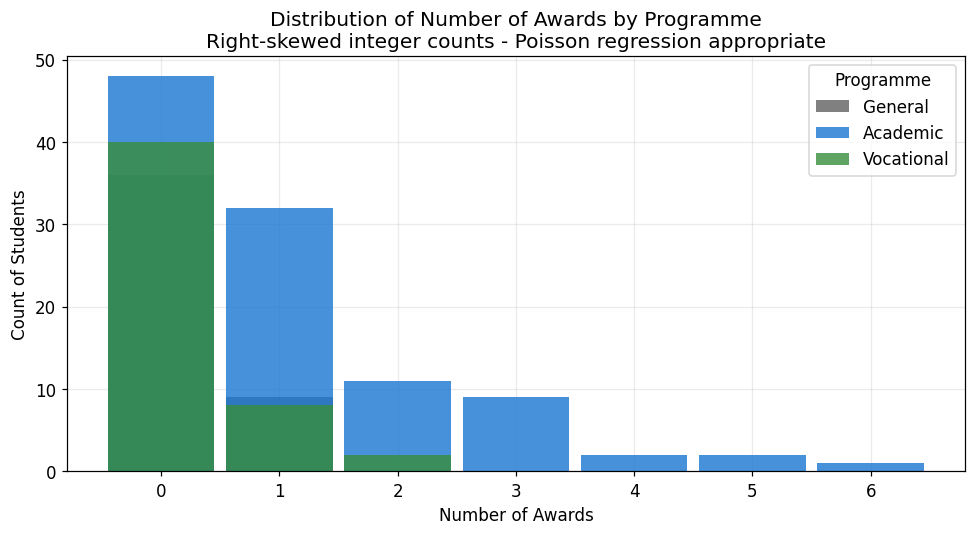

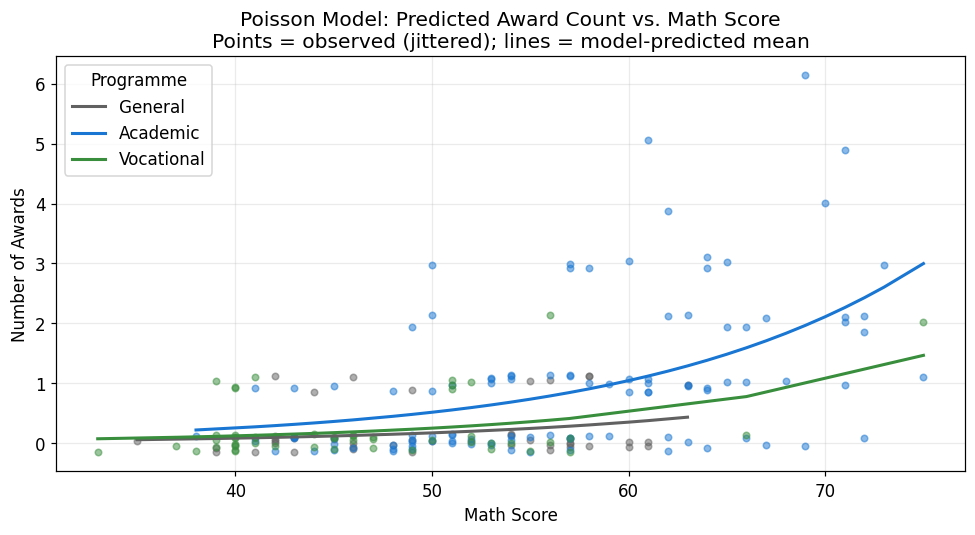

  predicted awards at math=70, Academic = 2.11
  predicted awards at math=70, General = 0.71


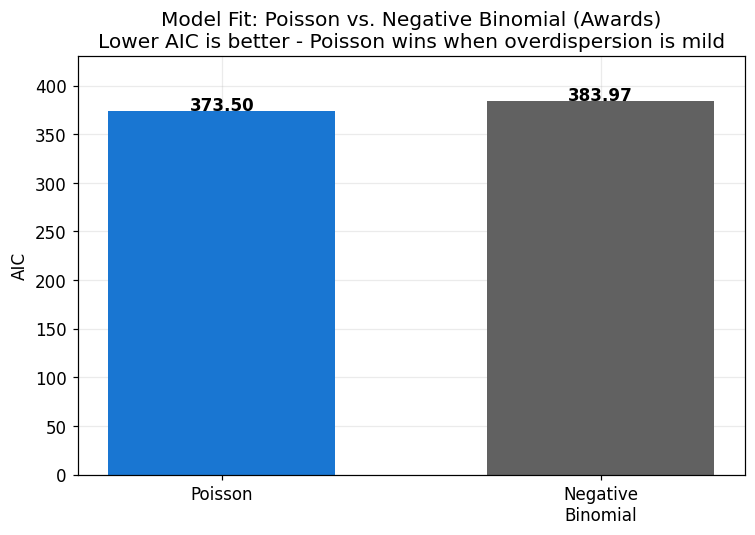

In [4]:
# =============================================================================
# PART 2 - NEGATIVE BINOMIAL REGRESSION: is the extra parameter justified?
# -----------------------------------------------------------------------------
# Negative binomial adds a dispersion parameter so the variance can exceed the
# mean. When overdispersion is only mild, the added parameter is not justified
# and Poisson fits better (lower AIC) - a useful calibration point that negative
# binomial is not automatically superior to Poisson.
# =============================================================================
# alpha=1.0 sets the dispersion parameter explicitly (the standard default) so
# the fit is fully specified and reproducible.
nb = sm.GLM.from_formula("num_awards ~ C(prog) + math", data=awards,
                         family=sm.families.NegativeBinomial(alpha=1.0)).fit()
print("\nNegative Binomial AIC = %.2f  (Poisson AIC = %.2f, diff = %.2f)"
      % (nb.aic, poisson.aic, nb.aic - poisson.aic))

# --- Figure 1: award distribution by programme (the diagnostic that motivates
# a count model in the first place). ---
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(-0.5, awards.num_awards.max() + 1.5, 1)
for prog, color in zip(["General", "Academic", "Vocational"],
                       [C_GREY, C_BLUE, C_GREEN]):
    ax.hist(awards.loc[awards.prog == prog, "num_awards"], bins=bins, alpha=0.8,
            label=prog, color=color, rwidth=0.9)
ax.set_title("Distribution of Number of Awards by Programme\n"
             "Right-skewed integer counts - Poisson regression appropriate")
ax.set_xlabel("Number of Awards"); ax.set_ylabel("Count of Students")
ax.legend(title="Programme")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig01-award-distribution.png")); plt.show()

# --- Figure 2: observed counts (jittered) vs Poisson predicted means by math
# score and programme. ---
awards["pred"] = poisson.predict(awards)
fig, ax = plt.subplots(figsize=(9, 5))
rng_j = np.random.default_rng(0)
for prog, color in zip(["General", "Academic", "Vocational"],
                       [C_GREY, C_BLUE, C_GREEN]):
    sub = awards[awards.prog == prog].sort_values("math")
    jitter = rng_j.uniform(-0.15, 0.15, len(sub))
    ax.scatter(sub.math, sub.num_awards + jitter, s=18, alpha=0.5, color=color)
    ax.plot(sub.math, sub.pred, color=color, linewidth=2, label=prog)
ax.set_title("Poisson Model: Predicted Award Count vs. Math Score\n"
             "Points = observed (jittered); lines = model-predicted mean")
ax.set_xlabel("Math Score"); ax.set_ylabel("Number of Awards")
ax.legend(title="Programme")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig02-poisson-predicted.png")); plt.show()
# Report the predicted means at math = 70 for the figure interpretation.
for prog in ["Academic", "General"]:
    row = pd.DataFrame({"prog": [prog], "math": [70]})
    print("  predicted awards at math=70, %s = %.2f"
          % (prog, poisson.predict(row).iloc[0]))

# --- Figure 3: AIC comparison between Poisson and negative binomial. ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Poisson", "Negative\nBinomial"], [poisson.aic, nb.aic],
       color=[C_BLUE, C_GREY], width=0.6)
for x, v in zip([0, 1], [poisson.aic, nb.aic]):
    ax.text(x, v + 1, "%.2f" % v, ha="center", fontweight="bold")
ax.set_title("Model Fit: Poisson vs. Negative Binomial (Awards)\n"
             "Lower AIC is better - Poisson wins when overdispersion is mild")
ax.set_ylabel("AIC"); ax.set_ylim(0, max(poisson.aic, nb.aic) * 1.12)
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig03-poisson-nb-aic.png")); plt.show()

## Part 3 — Ordinal logistic regression (perceived government poverty effort)


PART 3: ORDINAL  (N = 5381)  AIC = 10420.6
  religion     beta=+0.180  OR=1.197  p=0.0201
  degree       beta=+0.141  OR=1.151  p=0.0332
  Norway       beta=-0.322  OR=0.724  p=0.0000
  Sweden       beta=-0.603  OR=0.547  p=0.0000
  USA          beta=+0.618  OR=1.855  p=0.0000
  age          beta=+0.011  OR=1.011  p=0.0000
  gender_male  beta=+0.176  OR=1.193  p=0.0009
  profile (USA, religious, college, 40, female): TooLittle=0.342 AboutRight=0.417 TooMuch=0.241
  profile (Australia, religious, college, 40, female): TooLittle=0.491 AboutRight=0.363 TooMuch=0.146


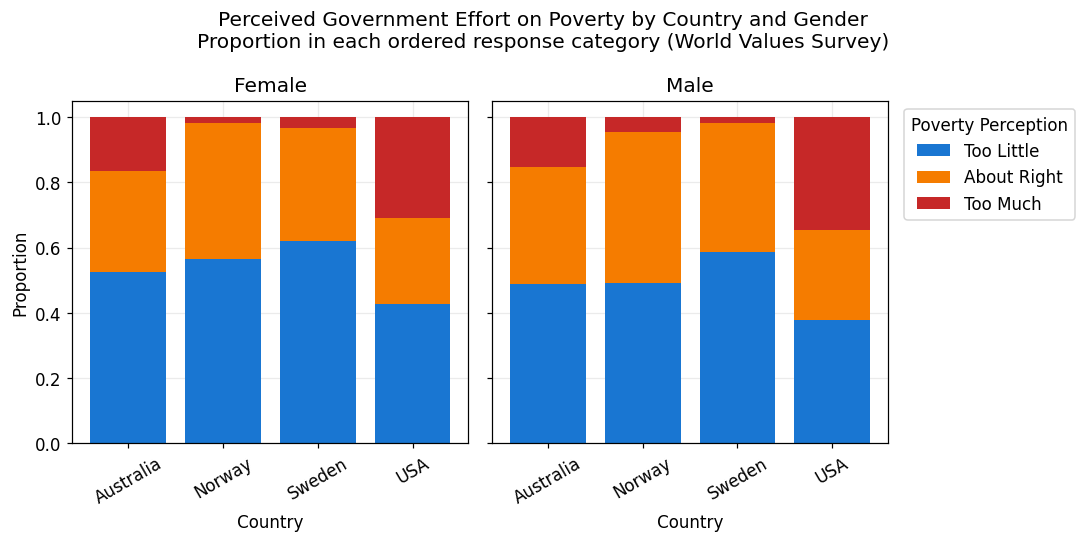

In [5]:
# =============================================================================
# PART 3 - ORDINAL LOGISTIC REGRESSION: perceived government poverty effort
# -----------------------------------------------------------------------------
# Ordinal logistic regression (proportional-odds model) handles ordered
# categorical outcomes whose category spacing is unknown. Treating the three
# ordered responses as a continuous 1-3 score and running OLS would force an
# equal-interval assumption and return a single slope across thresholds, hiding
# the country-level pattern the ordinal model reveals.
# =============================================================================
wv = pd.read_csv(os.path.join(HERE, "01b_world_values.csv"))
wv["poverty"] = pd.Categorical(
    wv["poverty"], categories=["Too Little", "About Right", "Too Much"], ordered=True)
# Build the design matrix: binary religion/degree, country dummies (reference =
# Australia), age, and a male indicator (reference = female).
X = pd.DataFrame(index=wv.index)
X["religion"] = (wv.religion == "yes").astype(float)
X["degree"] = (wv.degree == "yes").astype(float)
for c in ["Norway", "Sweden", "USA"]:
    X[c] = (wv.country == c).astype(float)
X["age"] = wv.age.astype(float)
X["gender_male"] = (wv.gender == "male").astype(float)

ordm = OrderedModel(wv["poverty"], X, distr="logit").fit(method="bfgs", disp=0)
print("\n" + "=" * 70)
print("PART 3: ORDINAL  (N = %d)  AIC = %.1f" % (len(wv), ordm.aic))
for k in X.columns:
    b = ordm.params[k]; z = b / ordm.bse[k]; p = 2 * (1 - stats.norm.cdf(abs(z)))
    print("  %-12s beta=%+.3f  OR=%.3f  p=%.4f" % (k, b, np.exp(b), p))
# Predicted probabilities for two representative profiles to make the abstract
# log-odds concrete.
for label, usa in [("USA", 1.0), ("Australia", 0.0)]:
    prof = pd.DataFrame([{"religion": 1, "degree": 1, "Norway": 0, "Sweden": 0,
                          "USA": usa, "age": 40, "gender_male": 0}])[X.columns]
    pp = np.asarray(ordm.predict(prof))[0]
    print("  profile (%s, religious, college, 40, female): "
          "TooLittle=%.3f AboutRight=%.3f TooMuch=%.3f"
          % (label, pp[0], pp[1], pp[2]))

# --- Figure 4: proportional stacked bars of poverty perception by country and
# gender. ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
cats = ["Too Little", "About Right", "Too Much"]
colors = [C_BLUE, C_ORANGE, C_RED]
countries = ["Australia", "Norway", "Sweden", "USA"]
for ax, g in zip(axes, ["female", "male"]):
    sub = wv[wv.gender == g]
    props = (sub.groupby("country")["poverty"].value_counts(normalize=True)
             .unstack().reindex(index=countries)[cats])
    bottom = np.zeros(len(countries))
    for cat, col in zip(cats, colors):
        ax.bar(countries, props[cat].values, bottom=bottom, color=col, label=cat)
        bottom += props[cat].values
    ax.set_title(g.capitalize()); ax.set_xlabel("Country")
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("Proportion")
axes[1].legend(title="Poverty Perception", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Perceived Government Effort on Poverty by Country and Gender\n"
             "Proportion in each ordered response category (World Values Survey)")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig04-ordinal-poverty-country.png")); plt.show()

## Part 4 — Truncated regression (academic scores with a sampling ceiling)


PART 4: TRUNCATED (N = 178)  max score = 96  mean = 74.2
  OLS   : intercept=39.497  langscore=0.463
  Trunc : intercept=39.326  langscore=0.466  sigma=7.491


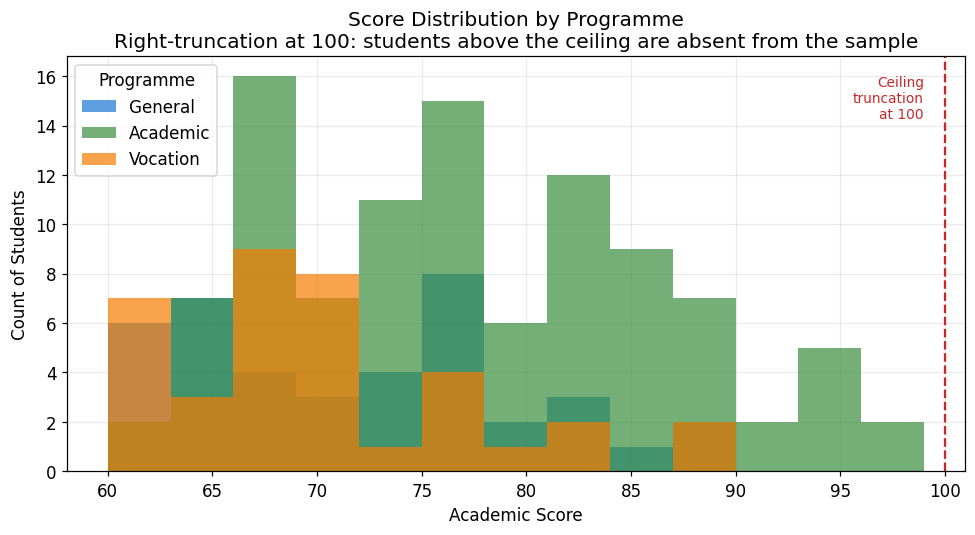

In [6]:
# =============================================================================
# PART 4 - TRUNCATED REGRESSION: academic scores with a sampling ceiling
# -----------------------------------------------------------------------------
# Truncated regression is a maximum-likelihood estimator for samples where
# out-of-range observations are entirely ABSENT (not recorded at a boundary).
# Here no score reaches the ceiling of 100. The truncated likelihood conditions
# each observation on being within the observed range; OLS ignores this and
# treats the observed range as the full distribution.
# =============================================================================
sc = pd.read_csv(os.path.join(HERE, "01c_scores.csv"))
# Reference category = academic (alphabetical), so the intercept is the expected
# score for an academic-programme student at langscore = 0.
sc["prog"] = pd.Categorical(sc["prog"], categories=["academic", "general", "vocation"])
Xs = pd.get_dummies(sc["prog"], drop_first=True).astype(float)
Xs.insert(0, "langscore", sc["langscore"].astype(float))
Xs = sm.add_constant(Xs)
y = sc["score"].astype(float).values
Xm = Xs.values
ols_sc = sm.OLS(y, Xm).fit()

# Maximum-likelihood truncated-normal regression, right-truncated at 100.
def trunc_negll(par):
    b, s = par[:-1], np.exp(par[-1])
    mu = Xm @ b
    return -(stats.norm.logpdf(y, mu, s) - stats.norm.logcdf((100 - mu) / s)).sum()

tr = optimize.minimize(trunc_negll, np.append(ols_sc.params, np.log(np.sqrt(ols_sc.mse_resid))),
                       method="BFGS").x
print("\n" + "=" * 70)
print("PART 4: TRUNCATED (N = %d)  max score = %d  mean = %.1f"
      % (len(sc), sc.score.max(), sc.score.mean()))
print("  OLS   : intercept=%.3f  langscore=%.3f" % (ols_sc.params[0], ols_sc.params[1]))
print("  Trunc : intercept=%.3f  langscore=%.3f  sigma=%.3f"
      % (tr[0], tr[1], np.exp(tr[-1])))

# --- Figure 5: score distribution by programme with the truncation ceiling. ---
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.arange(sc.score.min() - 1, 102, 3)
for prog, color in zip(["general", "academic", "vocation"], [C_BLUE, C_GREEN, C_ORANGE]):
    ax.hist(sc.loc[sc.prog == prog, "score"], bins=bins, alpha=0.7,
            label=prog.capitalize(), color=color)
ax.axvline(100, ls="--", color=C_RED, lw=1.5)
ax.text(99, ax.get_ylim()[1] * 0.85, "Ceiling\ntruncation\nat 100",
        color=C_RED, ha="right", fontsize=9)
ax.set_title("Score Distribution by Programme\n"
             "Right-truncation at 100: students above the ceiling are absent from the sample")
ax.set_xlabel("Academic Score"); ax.set_ylabel("Count of Students")
ax.legend(title="Programme")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig05-truncated-score-dist.png")); plt.show()

## Part 5 — Tobit regression (censored outcome, synthetic illustrative data)


PART 5: TOBIT (synthetic, N = 601)  zeros = 339 (56.4%)
  predictor       OLS       Tobit
  const         +2.968    +3.489
  age           -0.003    -0.008
  yearsmarried  +0.051    +0.117
  religiousness -0.244    -0.532
  occupation    +0.050    +0.099
  rating        -0.534    -1.114
  sigma (Tobit) = 2.598


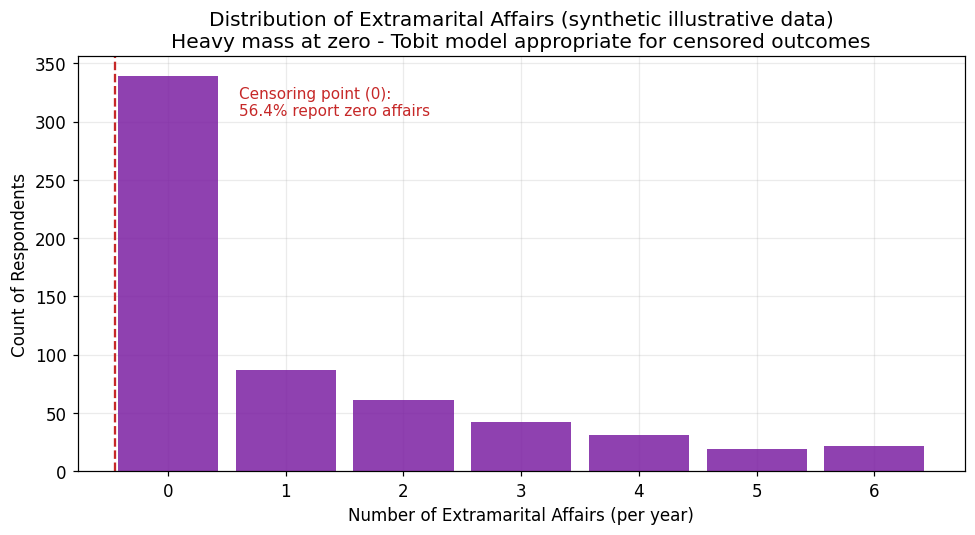

  predicted (latent) by rating:
    rating=1  Tobit=+1.90  OLS=+2.22
    rating=2  Tobit=+0.79  OLS=+1.68
    rating=3  Tobit=-0.33  OLS=+1.15
    rating=4  Tobit=-1.44  OLS=+0.62
    rating=5  Tobit=-2.55  OLS=+0.08
  Tobit drop 1->5 = 4.45 ; OLS drop 1->5 = 2.14


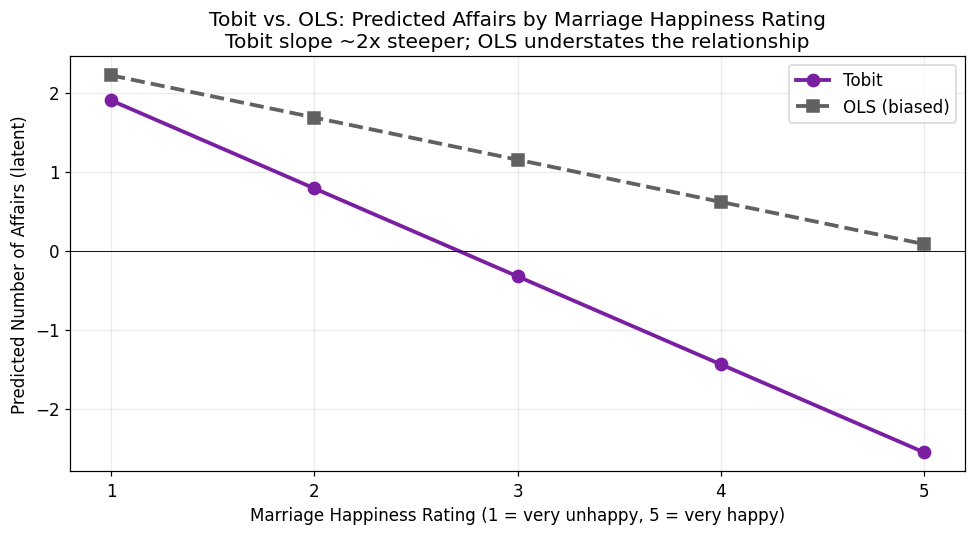


All seven figures written to docs/figures/. Pipeline complete.


In [7]:
# =============================================================================
# PART 5 - TOBIT REGRESSION: censored outcome with a heavy mass at zero
# -----------------------------------------------------------------------------
# Tobit (censored regression) models a latent continuous outcome that we observe
# only above a boundary. When many observations pile up at the floor, OLS treats
# those zeros as exact data and flattens the fitted line, attenuating every
# coefficient toward zero. Tobit recovers the latent relationship.
#
# Data note: this is a SYNTHETIC illustrative dataset built to mirror the
# structure of classic extramarital-affairs studies (heavy censoring at zero,
# marriage rating as the dominant negative predictor). It is generated
# deterministically below and saved to 01d_affairs.csv so the demonstration is
# fully reproducible. No real individuals are represented.
# =============================================================================
rng = np.random.default_rng(88)  # fixed seed -> identical dataset on every run
n = 601
age = rng.normal(32, 9, n).clip(17, 60)
ym = rng.normal(8, 5, n).clip(0.5, 25)
relig = rng.integers(1, 6, n).astype(float)      # religiousness 1-5
occ = rng.integers(1, 8, n).astype(float)        # occupation 1-7
rating = rng.integers(1, 6, n).astype(float)     # marriage happiness 1-5
# Latent propensity: marriage rating is the dominant negative driver; the
# observed count is the latent value floored at zero and capped at 6.
latent = (3.0 + 0.018 * age + 0.12 * ym - 0.55 * relig + 0.03 * occ
          - 0.95 * rating + rng.normal(0, 2.4, n))
affairs = np.clip(np.round(latent), 0, 6).astype(int)
aff = pd.DataFrame({"affairs": affairs, "age": age.round(0),
                    "yearsmarried": ym.round(1), "religiousness": relig,
                    "occupation": occ, "rating": rating})
aff.to_csv(os.path.join(HERE, "01d_affairs.csv"), index=False)

Xc = ["age", "yearsmarried", "religiousness", "occupation", "rating"]
Xa = sm.add_constant(aff[Xc].astype(float)).values
ya = aff["affairs"].astype(float).values
ols_aff = sm.OLS(ya, Xa).fit()

# Left-censored Tobit MLE (censoring point = 0).
cens = ya <= 0
def tobit_negll(par):
    b, s = par[:-1], np.exp(par[-1])
    mu = Xa @ b
    return -np.where(cens, stats.norm.logcdf((0 - mu) / s),
                     stats.norm.logpdf(ya, mu, s)).sum()

tb = optimize.minimize(tobit_negll, np.append(ols_aff.params, np.log(ya.std() + 1)),
                       method="BFGS").x
sigma = np.exp(tb[-1])
names = ["const"] + Xc
print("\n" + "=" * 70)
print("PART 5: TOBIT (synthetic, N = %d)  zeros = %d (%.1f%%)"
      % (n, int((aff.affairs == 0).sum()), (aff.affairs == 0).mean() * 100))
print("  predictor       OLS       Tobit")
for i, nm in enumerate(names):
    print("  %-13s %+.3f    %+.3f" % (nm, ols_aff.params[i], tb[i]))
print("  sigma (Tobit) = %.3f" % sigma)

# --- Figure 6: distribution of affairs with the censoring point at zero. ---
zero_pct = (aff.affairs == 0).mean() * 100
fig, ax = plt.subplots(figsize=(9, 5))
counts = aff.affairs.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=C_PURPLE, alpha=0.85, width=0.85)
ax.axvline(-0.45, ls="--", color=C_RED, lw=1.5)
ax.text(0.6, counts.max() * 0.9,
        "Censoring point (0):\n%.1f%% report zero affairs" % zero_pct,
        color=C_RED, fontsize=10)
ax.set_title("Distribution of Extramarital Affairs (synthetic illustrative data)\n"
             "Heavy mass at zero - Tobit model appropriate for censored outcomes")
ax.set_xlabel("Number of Extramarital Affairs (per year)")
ax.set_ylabel("Count of Respondents")
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig06-tobit-affairs-dist.png")); plt.show()

# --- Figure 7: Tobit vs OLS predicted latent affairs across marriage rating,
# all other predictors held at their sample means. ---
means = aff[["age", "yearsmarried", "religiousness", "occupation"]].mean()
ratings = np.array([1, 2, 3, 4, 5])
grid = np.column_stack([np.ones(5), np.repeat(means["age"], 5),
                        np.repeat(means["yearsmarried"], 5),
                        np.repeat(means["religiousness"], 5),
                        np.repeat(means["occupation"], 5), ratings])
pred_tobit = grid @ tb[:-1]
pred_ols = grid @ ols_aff.params
print("  predicted (latent) by rating:")
for r, t, o in zip(ratings, pred_tobit, pred_ols):
    print("    rating=%d  Tobit=%+.2f  OLS=%+.2f" % (r, t, o))
print("  Tobit drop 1->5 = %.2f ; OLS drop 1->5 = %.2f"
      % (pred_tobit[0] - pred_tobit[4], pred_ols[0] - pred_ols[4]))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ratings, pred_tobit, "-o", color=C_PURPLE, lw=2.5, ms=8, label="Tobit")
ax.plot(ratings, pred_ols, "--s", color=C_GREY, lw=2.5, ms=8, label="OLS (biased)")
ax.axhline(0, color="black", lw=0.6)
ax.set_title("Tobit vs. OLS: Predicted Affairs by Marriage Happiness Rating\n"
             "Tobit slope ~2x steeper; OLS understates the relationship")
ax.set_xlabel("Marriage Happiness Rating (1 = very unhappy, 5 = very happy)")
ax.set_ylabel("Predicted Number of Affairs (latent)")
ax.set_xticks(ratings); ax.legend()
fig.tight_layout(); fig.savefig(os.path.join(FIG, "fig07-tobit-predicted.png")); plt.show()

print("\nAll seven figures written to docs/figures/. Pipeline complete.")